# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV841"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv841')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv841/lv841-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV841,gene_band
0,HUWE1,2.825866,NaN
1,DYNC1H1,2.726632,14q32.31
2,MYH9,2.663758,22q12.3
3,FLNA,2.637014,NaN
4,NDST1,2.581659,5q33.1
5,NOTCH2,2.547009,1p12
6,PLXNA1,2.539725,3q21.3
7,CDC42BPB,2.528263,14q32.32
8,PRPF8,2.426853,17p13.3
9,SPTAN1,2.424911,9q34.11


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 16:53:42,674 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 16:53:42,674 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP057205, SRP051102, SRP007461, SRP034666, SRP014591, SRP015964, SRP057745, SRP042620, SRP017972, SRP021214, SRP018719, SRP049004, SRP055101, SRP038702, SRP010038, SRP008331, SRP017142, SRP039348, SRP061426, SRP059692, SRP009659, SRP006970, SRP014842, SRP001893, SRP045639, SRP052706, SRP026537, SRP048761, SRP013773, SRP056076, SRP006912, SRP012295, SRP067836, SRP052740, SRP009474, SRP038963, SRP022913, SRP050374, SRP043593, SRP055475, SRP044763, SRP004637, SRP011903, SRP002079, SRP012557, SRP043960, SRP007481, SRP037718, SRP018883, SRP016790, SRP043644, SRP018861, SRP049391, SRP059643, SRP033250, SRP029434, SRP061380, SRP020544, SRP045501, SRP031849, SRP017378, SRP040327, SRP051595, SRP060650, SRP040243, SRP021134, SRP033711, SRP043510, SRP007338, SRP050954, SRP045421, SRP058804, SRP042184, SRP051674, SRP007403, SRP052879, SRP017294, SRP051772, SRP044611, SRP018218, SRP041228, SRP028570, SRP010054, SRP046266, SRP006561, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (82 != 85)
  warnings.warn(


In [12]:
lv_data.shape

(1432, 102)

In [13]:
lv_data.head()

cell line gfp cd13 ssea4 tra160 cell ;ome cell type  \
project   run                                                                 
SRP057205 SRR1975508  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975507  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975506  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975505  Detroit 551  NA   NA    NA     NA       NaN       NaN   
          SRR1975503  Detroit 551   -   NA     +      +       NaN       NaN   

                     treated with time point library preparation protocol  \
project   run                                                               
SRP057205 SRR1975508          NaN        NaN                          NaN   
          SRR1975507          NaN        NaN                          NaN   
          SRR1975506          NaN        NaN                          NaN   
          SRR1975505          NaN        NaN                          NaN   
          SRR1975503          NaN        NaN                          NaN   

                      ... background cell line cell state tamoxifen treatment  \
project   run         ...                                                       
SRP057205 SRR1975508  ...                  NaN        NaN                 NaN   
          SRR1975507  ...                  NaN        NaN                 NaN   
          SRR1975506  ...                  NaN        NaN                 NaN   
          SRR1975505  ...                  NaN        NaN                 NaN   
          SRR1975503  ...                  NaN        NaN                 NaN   

                     strain condition/treatment time-point  rep  \
project   run                                                     
SRP057205 SRR1975508    NaN                 NaN        NaN  NaN   
          SRR1975507    NaN                 NaN        NaN  NaN   
          SRR1975506    NaN                 NaN        NaN  NaN   
          SRR1975505    NaN                 NaN        NaN  NaN   
          SRR1975503    NaN                 NaN        NaN  NaN   

                     drug treatment vector     LV841  
project   run                                         
SRP057205 SRR1975508            NaN    NaN  0.246417  
          SRR1975507            NaN    NaN  0.199113  
          SRR1975506            NaN    NaN  0.229948  
          SRR1975505            NaN    NaN  0.240652  
          SRR1975503            NaN    NaN  0.091774  

[5 rows x 102 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

transfected with                                               0.115223
rna fraction                                                   0.095896
cell ;ome                                                      0.083273
time point                                                     0.083273
rin                                                            0.083273
library preparation protocol                                   0.083273
ssea4                                                          0.060942
tra160                                                         0.060942
cd13                                                           0.060942
gfp                                                            0.060942
treated with                                                   0.058912
photoactivatable ribonucleoside and crosslinking wavelength    0.054895
immunoprecipitated protein                                     0.054895
replicate                                                      0

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

tissue       0.031253
cell line    0.025596
cell type    0.024983
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [17]:
lv_attrs_selected = [
    "tissue",
    "cell type",
    "cell line",
]

In [18]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [19]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [20]:
_tmp_seq[0]

tissue  \
project   run                                                             
SRP057205 SRR1975456                                                NaN   
          SRR1975455                                                NaN   
SRP051102 SRR1707913                                                NaN   
SRP034666 SRR1056281                                                NaN   
SRP057205 SRR1975457                                                NaN   
          SRR1975458                                                NaN   
SRP014591 SRR527729                                                 NaN   
SRP034666 SRR1056282                                                NaN   
SRP015964 SRR578756                                                 NaN   
SRP057745 SRR2000459                                                NaN   
          SRR2000458                                                NaN   
SRP034666 SRR1056280                                                NaN   
SRP051102 SRR1707905                                                NaN   
SRP042620 SRR1313187  Uninvolved Breast Tissue Adjacent to ER+ Prima...   
SRP017972 SRR649550                                                 NaN   
SRP051102 SRR1707914                                                NaN   
          SRR1707915                                                NaN   
SRP017972 SRR649552                                                 NaN   
SRP051102 SRR1707904                                                NaN   
SRP017972 SRR649545                                                 NaN   
SRP051102 SRR1707903                                                NaN   
SRP017972 SRR649551                                                 NaN   
SRP042620 SRR1313192  Uninvolved Breast Tissue Adjacent to ER+ Prima...   
SRP014591 SRR527730                                                 NaN   
SRP021214 SRR831700                                                 NaN   

                                                   cell type  \
project   run                                                  
SRP057205 SRR1975456                                     NaN   
          SRR1975455                                     NaN   
SRP051102 SRR1707913  Immortalized prostate cancer cell line   
SRP034666 SRR1056281                                     NaN   
SRP057205 SRR1975457                                     NaN   
          SRR1975458                                     NaN   
SRP014591 SRR527729                                      NaN   
SRP034666 SRR1056282                                     NaN   
SRP015964 SRR578756                                      NaN   
SRP057745 SRR2000459                                     NaN   
          SRR2000458                                     NaN   
SRP034666 SRR1056280                                     NaN   
SRP051102 SRR1707905  Immortalized prostate cancer cell line   
SRP042620 SRR1313187                                     NaN   
SRP017972 SRR649550                                      NaN   
SRP051102 SRR1707914  Immortalized prostate cancer cell line   
          SRR1707915  Immortalized prostate cancer cell line   
SRP017972 SRR649552                                      NaN   
SRP051102 SRR1707904  Immortalized prostate cancer cell line   
SRP017972 SRR649545                                      NaN   
SRP051102 SRR1707903  Immortalized prostate cancer cell line   
SRP017972 SRR649551                                      NaN   
SRP042620 SRR1313192                                     NaN   
SRP014591 SRR527730                                      NaN   
SRP021214 SRR831700                              tumor cells   

                                                              cell line  \
project   run                                                             
SRP057205 SRR1975456                                        Detroit 551   
          SRR1975455                                        Detroit 551   
SRP051102 

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [21]:
_tmp_seq[1]

,,tissue,cell type,cell line,LV841
project,run,,,,
SRP057745,SRR2000468,NaN,NaN,HEK293T,0.535259
SRP021214,SRR831699,NaN,tumor cells,NaN,0.529632
SRP042620,SRR1313190,Uninvolved Breast Tissue Adjacent to ER+ Prima...,NaN,NaN,0.527832
SRP018719,SRR742817,NaN,NaN,293S,0.523638
SRP017972,SRR649546,NaN,NaN,NaN,0.518582
SRP049004,SRR1614284,NaN,NaN,Dermal Fibroblast from Coriell Institute (GM03...,0.516923
SRP017972,SRR649543,NaN,NaN,NaN,0.516631
SRP042620,SRR1313084,Breast Cancer Cell Line,NaN,NaN,0.512996
SRP055101,SRR1806596,NaN,endothelial,NaN,0.511229


Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [22]:
# list the top 10 samples from this project
lv_data.loc[["SRP035864"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP035864'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [23]:
SELECTED_ATTRIBUTES = [
    "tissue",
    "cell type",
    "cell line",
]

## Get a single attribute with "cell type/tissue" information

In [24]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [25]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [26]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [27]:
plot_data.head(20)

tissue  \
project   run                                                             
SRP057205 SRR1975456                                        Detroit 551   
          SRR1975455                                        Detroit 551   
SRP051102 SRR1707913             Immortalized prostate cancer cell line   
SRP034666 SRR1056281                        osteosarcoma U2OS cell line   
SRP057205 SRR1975457                                        Detroit 551   
          SRR1975458                                        Detroit 551   
SRP014591 SRR527729   FlpIn T-Rex Human embryonic kidney 293 stable ...   
SRP034666 SRR1056282                        osteosarcoma U2OS cell line   
SRP015964 SRR578756                                                HL60   
SRP057745 SRR2000459                                            HEK293T   
          SRR2000458                                            HEK293T   
SRP034666 SRR1056280                        osteosarcoma U2OS cell line   
SRP051102 SRR1707905             Immortalized prostate cancer cell line   
SRP042620 SRR1313187  Uninvolved Breast Tissue Adjacent to ER+ Prima...   
SRP017972 SRR649550                                     NOT CATEGORIZED   
SRP051102 SRR1707914             Immortalized prostate cancer cell line   
          SRR1707915             Immortalized prostate cancer cell line   
SRP017972 SRR649552                                     NOT CATEGORIZED   
SRP051102 SRR1707904             Immortalized prostate cancer cell line   
SRP017972 SRR649545                                     NOT CATEGORIZED   

                         LV841  
project   run                   
SRP057205 SRR1975456  0.830002  
          SRR1975455  0.829286  
SRP051102 SRR1707913  0.813365  
SRP034666 SRR1056281  0.711975  
SRP057205 SRR1975457  0.679944  
          SRR1975458  0.679696  
SRP014591 SRR527729   0.674934  
SRP034666 SRR1056282  0.667650  
SRP015964 SRR578756   0.642541  
SRP057745 SRR2000459  0.636427  
          SRR2000458  0.631242  
SRP034666 SRR1056280  0.623533  
SRP051102 SRR1707905  0.586969  
SRP042620 SRR1313187  0.575623  
SRP017972 SRR649550   0.565482  
SRP051102 SRR1707914  0.565326  
          SRR1707915  0.565276  
SRP017972 SRR649552   0.560465  
SRP051102 SRR1707904  0.559569  
SRP017972 SRR649545   0.550092

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [28]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [29]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [30]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [31]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [32]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [33]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [34]:
N_TOP_ATTRS = 10

In [35]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [36]:
len(attr_order)

10

In [37]:
attr_order[:5]

['Detroit 551',
 'Immortalized prostate cancer cell line',
 'osteosarcoma U2OS cell line',
 'FlpIn T-Rex Human embryonic kidney 293 stable cell line',
 'HL60']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

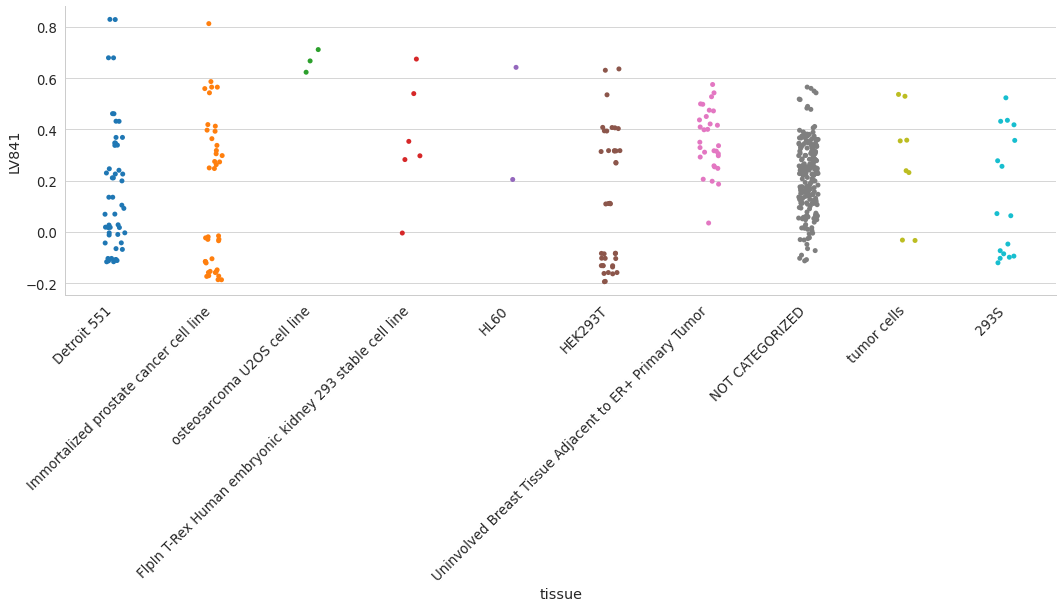

In [38]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [39]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("osteosarcoma")
    ]
    display(_tmp.head(20))

tissue     LV841
project   run                                              
SRP034666 SRR1056281  osteosarcoma U2OS cell line  0.711975
          SRR1056282  osteosarcoma U2OS cell line  0.667650
          SRR1056280  osteosarcoma U2OS cell line  0.623533

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP034666, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [40]:
# what is there in these projects?
lv_data.loc[["SRP034666"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line  \
project   run                                       
SRP034666 SRR1056281  osteosarcoma U2OS cell line   
          SRR1056282  osteosarcoma U2OS cell line   
          SRR1056280  osteosarcoma U2OS cell line   

                                                               antibody  \
project   run                                                             
SRP034666 SRR1056281    anti-CTCF (Abcam, cat# ab70303, lot# GR27477-7)   
          SRR1056282  anti-CTCF (Abcam, cat# ab70303, lot#s GR98618-...   
          SRR1056280    anti-CTCF (Abcam, cat# ab70303, lot# GR98618-4)   

                         LV841  
project   run                   
SRP034666 SRR1056281  0.711975  
          SRR1056282  0.667650  
          SRR1056280  0.623533

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.